In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

df = pd.read_csv('..\canteen_breakfast_data.csv')

In [132]:
df.head()

,date,breakfast_footfall_pct
0,2024-01-01,0.00
1,2024-01-02,74.88
2,2024-01-03,83.56
3,2024-01-04,79.98
4,2024-01-05,47.78


## Data Enrichment:

### Add Rain Data during the period

In [133]:
import requests
import pandas as pd
from datetime import datetime

def fetch_precipitation_data(latitude=18.5898, longitude=73.7997, start_date='2024-01-01', end_date='2025-12-31'):
    """
    Fetch historical precipitation data from Open-Meteo API for a given location and date range.
    
    Parameters:
    - latitude: Location latitude (default: Hinjewadi, Pune = 18.5898)
    - longitude: Location longitude (default: Hinjewadi, Pune = 73.7997)
    - start_date: Start date in format 'YYYY-MM-DD'
    - end_date: End date in format 'YYYY-MM-DD'
    
    Returns:
    - DataFrame with columns: date, precipitation_mm
    """
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "precipitation_sum",
        "timezone": "Asia/Kolkata"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        
        # Extract precipitation data
        dates = data['daily']['time']
        precipitation = data['daily']['precipitation_sum']
        
        # Create DataFrame
        df_rain = pd.DataFrame({
            'date': pd.to_datetime(dates),
            'precipitation_mm': precipitation
        })
        
        print(f"✓ Successfully fetched precipitation data")
        print(f"  Location: Hinjewadi, Pune ({latitude}°N, {longitude}°E)")
        print(f"  Date range: {start_date} to {end_date}")
        print(f"  Total records: {len(df_rain)}")
        print(f"  Precipitation range: {df_rain['precipitation_mm'].min():.1f}mm - {df_rain['precipitation_mm'].max():.1f}mm")
        
        return df_rain
    
    except requests.exceptions.RequestException as e:
        print(f"✗ Error fetching data: {e}")
        return None

# Fetch the precipitation data
print("Fetching precipitation data from Open-Meteo API...")
df_rain = fetch_precipitation_data()

# ensure df has datetime column named date
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

if df_rain is not None:
    # merge into main df by matching date (both lowercase)
    df = df.merge(df_rain.rename(columns={'date': 'date'}), on='date', how='left')
    print(f"\nMerged precipitation data, resulting dataframe has {len(df)} records")
    print(df[['date','precipitation_mm']].head(10))
else:
    # create placeholder column so later code doesn't break
    df['precipitation_mm'] = np.nan
    print("\nNo precipitation data available; column filled with NaN.")

# Adding rain category based on precipitation_mm
def categorize_rain(mm):
    if pd.isna(mm):
        return 'Unknown'
    elif mm == 0:
        return 'No Rain'
    elif mm < 20:
        return 'Light Rain'
    elif mm < 45:
        return 'Moderate Rain'
    else:
        return 'Heavy Rain'
    
# Apply rain categorization and prepare for feature engineering
df['rain_category'] = df['precipitation_mm'].apply(categorize_rain)

# Verify the rain categories were created
print(f"Rain categories created:")
print(df['rain_category'].value_counts())
print(f"\nDataframe shape before feature engineering: {df.shape}")

# Ensure date is sorted for time-series features
df = df.sort_values('date').reset_index(drop=True)


Fetching precipitation data from Open-Meteo API...
✓ Successfully fetched precipitation data
  Location: Hinjewadi, Pune (18.5898°N, 73.7997°E)
  Date range: 2024-01-01 to 2025-12-31
  Total records: 731
  Precipitation range: 0.0mm - 86.4mm

Merged precipitation data, resulting dataframe has 731 records
        date  precipitation_mm
0 2024-01-01               0.0
1 2024-01-02               0.0
2 2024-01-03               0.0
3 2024-01-04               0.0
4 2024-01-05               0.0
5 2024-01-06               0.0
6 2024-01-07               0.8
7 2024-01-08               0.3
8 2024-01-09               3.4
9 2024-01-10               7.3
Rain categories created:
rain_category
No Rain          381
Light Rain       312
Moderate Rain     30
Heavy Rain         8
Name: count, dtype: int64

Dataframe shape before feature engineering: (731, 4)


In [134]:
df.head(10)

,date,breakfast_footfall_pct,precipitation_mm,rain_category
0,2024-01-01,0.00,0.0,No Rain
1,2024-01-02,74.88,0.0,No Rain
2,2024-01-03,83.56,0.0,No Rain
3,2024-01-04,79.98,0.0,No Rain
4,2024-01-05,47.78,0.0,No Rain
5,2024-01-06,0.00,0.0,No Rain
6,2024-01-07,0.00,0.8,Light Rain
7,2024-01-08,60.25,0.3,Light Rain
8,2024-01-09,76.06,3.4,Light Rain
9,2024-01-10,79.56,7.3,Light Rain


### Add Pune location Holiday Data (can be detected from 0 attendance, but add it for more details)

In [135]:
# define Pune holidays for 2024 and 2025 and mark dataframe accordingly
# Pune office holidays for 2024 and 2025
pune_holidays_2024 = [
    '2024-01-01', # New Year
    '2024-01-26', # Republic Day
    '2024-03-25', # Holi
    '2024-03-29', # Good Friday
    '2024-04-09', # Gudi Padava
    '2024-05-01', # Maharashtra Day
    '2024-08-15', # Independence Day
    '2024-09-17', # Anant Chaturdashi
    '2024-10-02', # Gandhi Jayanti
    '2024-11-01', # Diwali - Laxmi Pujan
    '2024-12-25', # Christmas
]

pune_holidays_2025 = [
    '2025-01-01', # New Year
    '2025-01-26', # Republic Day
    '2025-03-14', # Holi
    '2025-03-31', # Ramzan ID
    '2025-04-18', # Good Friday
    '2025-05-01', # Maharashtra Day
    '2025-08-15', # Independence Day
    '2025-08-27', # Anant Chaturdashi
    '2025-10-02', # Gandhi Jayanti
    '2025-10-21', # Diwali - Laxmi Pujan
    '2025-10-22', # Diwali - Padwa
    '2025-12-25', # Christmas
]

# combine and convert to datetime
all_holidays = pd.to_datetime(pune_holidays_2024 + pune_holidays_2025)

# create flag
if 'date' in df.columns:
    df['is_holiday'] = df['date'].isin(all_holidays).astype(int)
else:
    df['is_holiday'] = 0  # fallback in case date column missing

print(f"Holidays marked in dataframe: {df['is_holiday'].sum()} days")

df.head(10)

Holidays marked in dataframe: 23 days


,date,breakfast_footfall_pct,precipitation_mm,rain_category,is_holiday
0,2024-01-01,0.00,0.0,No Rain,1
1,2024-01-02,74.88,0.0,No Rain,0
2,2024-01-03,83.56,0.0,No Rain,0
3,2024-01-04,79.98,0.0,No Rain,0
4,2024-01-05,47.78,0.0,No Rain,0
5,2024-01-06,0.00,0.0,No Rain,0
6,2024-01-07,0.00,0.8,Light Rain,0
7,2024-01-08,60.25,0.3,Light Rain,0
8,2024-01-09,76.06,3.4,Light Rain,0
9,2024-01-10,79.56,7.3,Light Rain,0


### Add Column for long weekend

In [136]:
# Identify long weekends and add flag to dataframe
# Case 1: Holiday on Thursday (people take leave on Friday)
# Case 2: Holiday on Tuesday (people take leave on Monday)

# ensure date is datetime and compute day-of-week for later flags
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day_name()
    # optional weekend flag if not already present
    if 'is_weekend' not in df.columns:
        df['is_weekend'] = df['date'].dt.weekday >= 5
        df['is_weekend'] = df['is_weekend'].astype(int)
else:
    raise KeyError("Dataframe does not contain a 'date' column")

# ensure columns are lowercase
for col in ['day', 'is_holiday']:
    if col not in df.columns:
        raise KeyError(f"Required column '{col}' not found in df")
    
# Adding month column as string for categorical encoding
df['month'] = df['date'].dt.month_name()

# initialize flag
df['is_long_weekend'] = 0

for i in range(len(df)):
    dow = df.loc[i, 'day']
    hol = df.loc[i, 'is_holiday']
    # Thursday holiday -> mark next day
    if dow == 'Thursday' and hol == 1:
        if i + 1 < len(df):
            df.loc[i + 1, 'is_long_weekend'] = 1
    # Tuesday holiday -> mark previous day
    elif dow == 'Tuesday' and hol == 1:
        if i - 1 >= 0:
            df.loc[i - 1, 'is_long_weekend'] = 1

# Summary statistics for long weekends
long_weekend_mask = df['is_long_weekend'] == 1
count_long_weekend = long_weekend_mask.sum()
mean_footfall_long_weekend = df.loc[long_weekend_mask, 'breakfast_footfall_pct'].mean()
print(f"Long-weekend days flagged: {count_long_weekend}")
print(f"Mean footfall during long weekends: {mean_footfall_long_weekend:.2f}%")

Long-weekend days flagged: 7
Mean footfall during long weekends: 14.62%


### Lag and rolling avg

In [137]:
df["rolling_7"] = (
    df["breakfast_footfall_pct"]
    .shift(1)  # shift to avoid data leakage
    .rolling(window=7)
    .mean()
    .fillna(method="bfill")  # backfill for the first 7 days
)

# Last 7 day data
df["lag_7"] = df["breakfast_footfall_pct"].shift(7).fillna(method="bfill")

# TODO: Add data visulization

## Remove Additional information and Get Dummies

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    731 non-null    datetime64[ns]
 1   breakfast_footfall_pct  731 non-null    float64       
 2   precipitation_mm        731 non-null    float64       
 3   rain_category           731 non-null    object        
 4   is_holiday              731 non-null    int64         
 5   day                     731 non-null    object        
 6   is_weekend              731 non-null    int64         
 7   month                   731 non-null    object        
 8   is_long_weekend         731 non-null    int64         
 9   rolling_7               731 non-null    float64       
 10  lag_7                   731 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 62.9+ KB


In [139]:
# 1. Filter for weekdays only
df_ml = df[df['is_weekend'] == 0].copy()
print(f"After filtering weekdays: {len(df_ml)} records")

# 2. Identify categorical features to encode
categorical_cols = ['day', 'rain_category', 'month']

# 3. Create one-hot encoding for categorical features
df_final = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True, prefix=['day', 'rain', 'mon'])
print(f"After get_dummies: {df_final.shape}")

# 4. Define columns to drop (data leakage & non-features)
cols_to_drop = ['date', 'precipitation_mm', 'breakfast_footfall_pct']

# 5. Prepare X and Y
X = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns])
Y = df_final['breakfast_footfall_pct']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {Y.shape}")
print(f"\nFeatures included: {list(X.columns)}")
X.head()

After filtering weekdays: 523 records
After get_dummies: (523, 26)
Feature matrix shape: (523, 23)
Target vector shape: (523,)

Features included: ['is_holiday', 'is_weekend', 'is_long_weekend', 'rolling_7', 'lag_7', 'day_Monday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'rain_Light Rain', 'rain_Moderate Rain', 'rain_No Rain', 'mon_August', 'mon_December', 'mon_February', 'mon_January', 'mon_July', 'mon_June', 'mon_March', 'mon_May', 'mon_November', 'mon_October', 'mon_September']


,is_holiday,is_weekend,is_long_weekend,rolling_7,lag_7,day_Monday,day_Thursday,day_Tuesday,day_Wednesday,rain_Light Rain,...,mon_December,mon_February,mon_January,mon_July,mon_June,mon_March,mon_May,mon_November,mon_October,mon_September
0,1,0,0,40.885714,0.0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,0,0,40.885714,0.0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,0,0,0,40.885714,0.0,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,0,40.885714,0.0,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,0,0,0,40.885714,0.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


### Machine Learning: Training & Linear Regression Evaluation

### The Time-Based Split

In real-world forecasting, you cannot use data from "next Wednesday" to predict "this Tuesday." A time-based split ensures you train on the past and test on the future (e.g., train on 2024, test on 2025).

Imports

In [140]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Data Split

In [141]:
# Sort by date first to ensure chronological order (already done during feature engineering)
# X and Y are already in chronological order

# Calculate the split point (80% point)
split_idx = int(len(X) * 0.8)

print(f"Total records: {len(X)}")
print(f"Training set: {split_idx} records")
print(f"Test set: {len(X) - split_idx} records")

# Split manually to preserve time order
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = Y.iloc[:split_idx]
y_test = Y.iloc[split_idx:]

print(f"\nTraining data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test data shape: X_test={X_test.shape}, y_test={y_test.shape}")


Total records: 523
Training set: 418 records
Test set: 105 records

Training data shape: X_train=(418, 23), y_train=(418,)
Test data shape: X_test=(105, 23), y_test=(105,)


Scale Fit & Transform

In [142]:
# 1. Initialize the Scaler
sc = StandardScaler()

# 2. FIT and TRANSFORM the training data
# This learns the mean/std from X_train and scales it
X_train_scaled = sc.fit_transform(X_train)

# 3. TRANSFORM the test data
# We DO NOT 'fit' on test data; we use the training parameters
X_test_scaled = sc.transform(X_test)

Model Training and evalution

### Linear Regression

MAE: 5.33%
R2 Score: 0.8773
RMSE: 8.26%


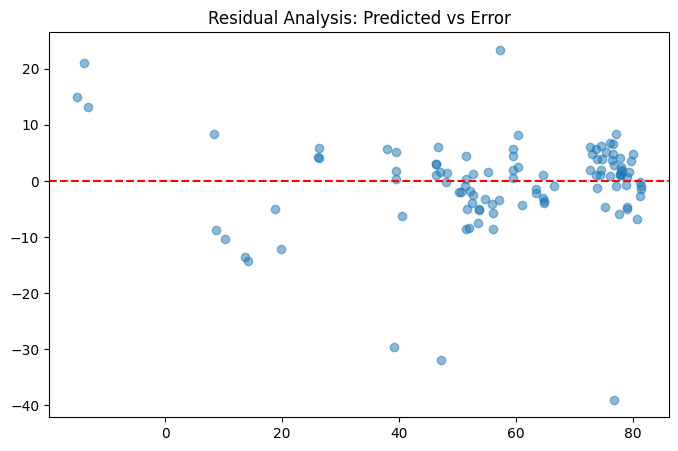

In [143]:
# Model Training
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# EVALUATION 
y_pred = lr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}%")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {rmse:.2f}%")

# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, (y_test - y_pred), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Analysis: Predicted vs Error')
plt.show()

### K-Nearest Neighbors (KNN) Model

In [144]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Find optimal K value by testing multiple neighbors
print("Finding optimal K value for KNN...")
print("-" * 60)

k_values = range(3, 31)  # Test k from 3 to 30
cv_scores_train = []
cv_scores_test = []
mae_scores = []
rmse_scores = []
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    
    # Metrics
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)
    
    cv_scores_train.append(train_score)
    cv_scores_test.append(test_score)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"K={k:2d} | Train R²={train_score:.4f} | Test R²={test_score:.4f} | MAE={mae:.2f}% | RMSE={rmse:.2f}% | R2={r2:.4f}")

# Find optimal K
optimal_k = k_values[np.argmax(cv_scores_test)]
print("-" * 60)
print(f"\n✓ OPTIMAL K VALUE: {optimal_k}")
print(f"  Best Test R² Score: {max(cv_scores_test):.4f}")


Finding optimal K value for KNN...
------------------------------------------------------------
K= 3 | Train R²=0.7842 | Test R²=0.5167 | MAE=10.02% | RMSE=16.39% | R2=0.5167


K= 4 | Train R²=0.7560 | Test R²=0.4693 | MAE=10.80% | RMSE=17.17% | R2=0.4693
K= 5 | Train R²=0.7196 | Test R²=0.4398 | MAE=11.72% | RMSE=17.65% | R2=0.4398
K= 6 | Train R²=0.6916 | Test R²=0.4005 | MAE=12.85% | RMSE=18.25% | R2=0.4005
K= 7 | Train R²=0.6612 | Test R²=0.4183 | MAE=12.87% | RMSE=17.98% | R2=0.4183
K= 8 | Train R²=0.6362 | Test R²=0.4191 | MAE=12.78% | RMSE=17.97% | R2=0.4191
K= 9 | Train R²=0.6169 | Test R²=0.4221 | MAE=12.79% | RMSE=17.92% | R2=0.4221
K=10 | Train R²=0.5829 | Test R²=0.4223 | MAE=12.77% | RMSE=17.92% | R2=0.4223
K=11 | Train R²=0.5510 | Test R²=0.4274 | MAE=12.82% | RMSE=17.84% | R2=0.4274
K=12 | Train R²=0.5118 | Test R²=0.4329 | MAE=12.83% | RMSE=17.75% | R2=0.4329
K=13 | Train R²=0.4786 | Test R²=0.4308 | MAE=13.00% | RMSE=17.79% | R2=0.4308
K=14 | Train R²=0.4541 | Test R²=0.4216 | MAE=13.24% | RMSE=17.93% | R2=0.4216
K=15 | Train R²=0.4456 | Test R²=0.3951 | MAE=13.41% | RMSE=18.33% | R2=0.3951
K=16 | Train R²=0.4497 | Test R²=0.3680 | MAE=13.70%

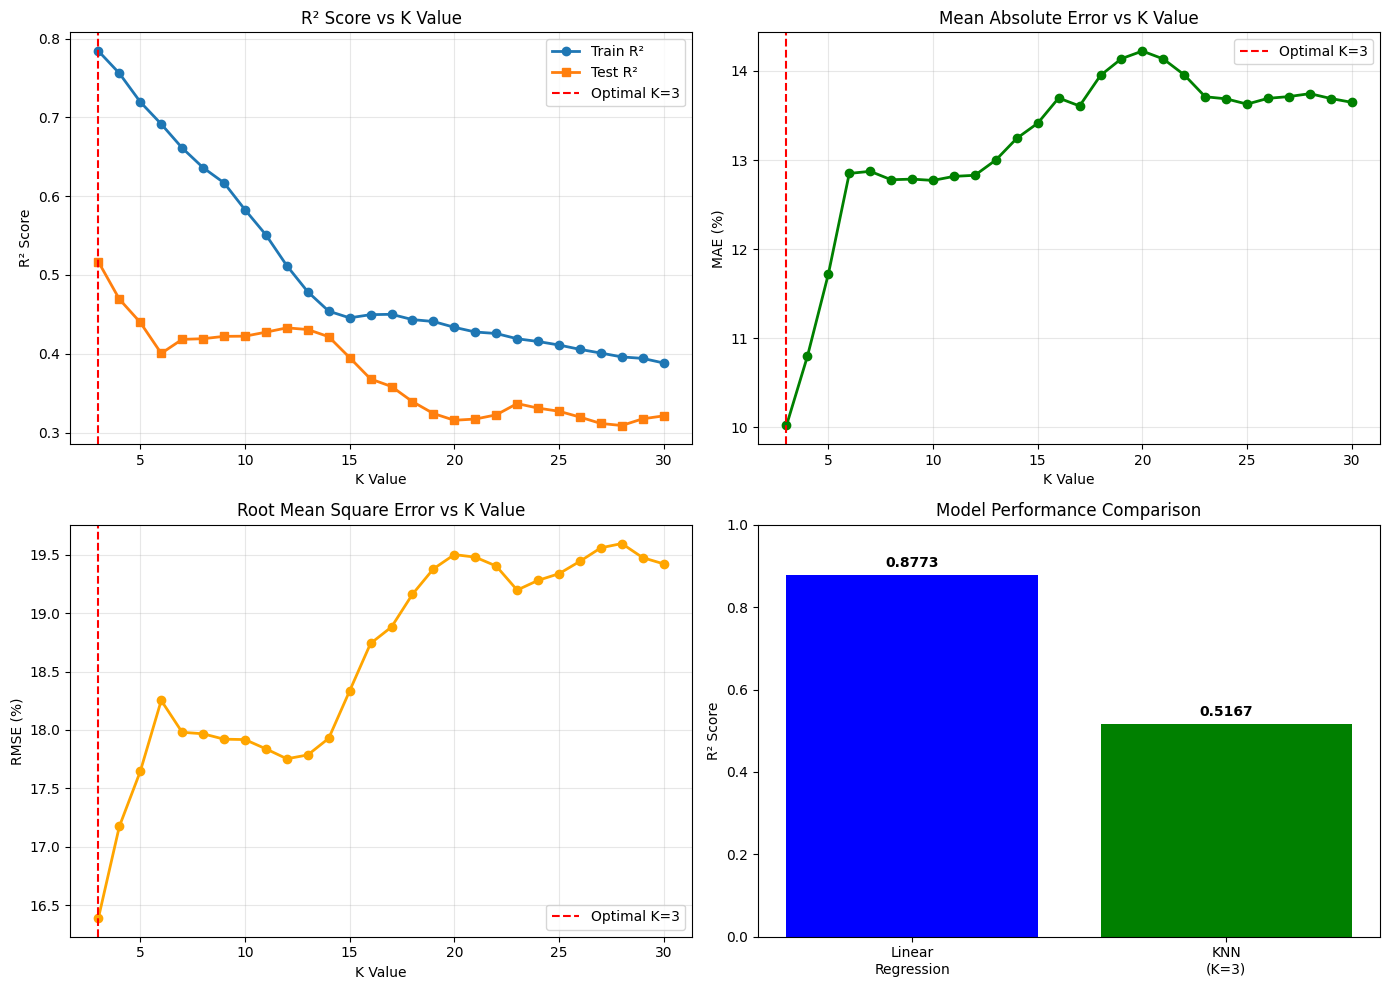

In [145]:
# Visualize KNN performance across different K values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: R² Scores
axes[0, 0].plot(k_values, cv_scores_train, 'o-', label='Train R²', linewidth=2)
axes[0, 0].plot(k_values, cv_scores_test, 's-', label='Test R²', linewidth=2)
axes[0, 0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0, 0].set_xlabel('K Value')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('R² Score vs K Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: MAE
axes[0, 1].plot(k_values, mae_scores, 'o-', color='green', linewidth=2)
axes[0, 1].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0, 1].set_xlabel('K Value')
axes[0, 1].set_ylabel('MAE (%)')
axes[0, 1].set_title('Mean Absolute Error vs K Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: RMSE
axes[1, 0].plot(k_values, rmse_scores, 'o-', color='orange', linewidth=2)
axes[1, 0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[1, 0].set_xlabel('K Value')
axes[1, 0].set_ylabel('RMSE (%)')
axes[1, 0].set_title('Root Mean Square Error vs K Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Model Comparison
axes[1, 1].bar(['Linear\nRegression', f'KNN\n(K={optimal_k})'], 
              [r2_score(y_test, lr.predict(X_test_scaled)), 
               r2_scores[optimal_k - 3]], color=['blue', 'green'])
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Model Performance Comparison')
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate([r2_score(y_test, lr.predict(X_test_scaled)), r2_scores[optimal_k - 3]]):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



KNN MODEL EVALUATION (K=3)
MAE:  10.02%
RMSE: 16.39%
R2 Score: 0.5167

MODEL COMPARISON
Model                R² Score        RMSE           
------------------------------------------------------------
Linear Regression    0.8773           8.26%
KNN (K=3)            0.5167           16.39%
------------------------------------------------------------
✓ Linear Regression performs better by 41.11%


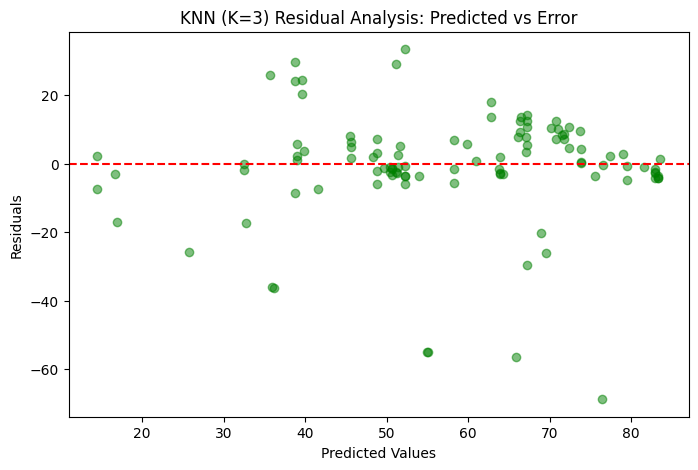

In [146]:
# Train KNN model with optimal K
knn_optimal = KNeighborsRegressor(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_optimal.predict(X_test_scaled)

# Evaluate KNN model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("\n" + "="*60)
print("KNN MODEL EVALUATION (K={})".format(optimal_k))
print("="*60)
print(f"MAE:  {mae_knn:.2f}%")
print(f"RMSE: {rmse_knn:.2f}%")
print(f"R2 Score: {r2_knn:.4f}")

# Compare with Linear Regression
lr_r2 = r2_score(y_test, lr.predict(X_test_scaled))
lr_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test_scaled)))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<20} {'R² Score':<15} {'RMSE':<15}")
print("-"*60)
print(f"{'Linear Regression':<20} {lr_r2:.4f}{'':<10} {lr_rmse:.2f}%")
print(f"{'KNN (K={})'.format(optimal_k):<20} {r2_knn:.4f}{'':<10} {rmse_knn:.2f}%")
print("-"*60)

if r2_knn > lr_r2:
    improvement = ((r2_knn - lr_r2) / lr_r2) * 100
    print(f"✓ KNN performs better by {improvement:.2f}%")
else:
    improvement = ((lr_r2 - r2_knn) / lr_r2) * 100
    print(f"✓ Linear Regression performs better by {improvement:.2f}%")

# Residual Plot for KNN
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_knn, (y_test - y_pred_knn), alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title(f'KNN (K={optimal_k}) Residual Analysis: Predicted vs Error')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


In [147]:
## Additional Models: Random Forest, Gradient Boosting & SVR

In [148]:
# Import additional models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

print("Training additional models...\n")

# 1. Random Forest
print("1. Training Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"   ✓ R² Score: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}%, MAE: {mae_rf:.2f}%")

# 2. Gradient Boosting
print("2. Training Gradient Boosting Regressor...")
gb = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f"   ✓ R² Score: {r2_gb:.4f}, RMSE: {rmse_gb:.2f}%, MAE: {mae_gb:.2f}%")

# 3. Support Vector Regression
print("3. Training Support Vector Regression...")
svr = SVR(kernel='rbf', C=100, epsilon=1.0)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)
print(f"   ✓ R² Score: {r2_svr:.4f}, RMSE: {rmse_svr:.2f}%, MAE: {mae_svr:.2f}%")

print("\n" + "="*70)


Training additional models...

1. Training Random Forest Regressor...
   ✓ R² Score: 0.6187, RMSE: 14.56%, MAE: 7.14%
2. Training Gradient Boosting Regressor...
   ✓ R² Score: 0.7189, RMSE: 12.50%, MAE: 6.37%
3. Training Support Vector Regression...
   ✓ R² Score: 0.7449, RMSE: 11.91%, MAE: 6.98%



In [149]:
# Comprehensive Model Comparison
models_data = {
    'Model': ['Linear Regression', f'KNN (K={optimal_k})', 'Random Forest', 'Gradient Boosting', 'SVR'],
    'R² Score': [lr_r2, r2_knn, r2_rf, r2_gb, r2_svr],
    'RMSE (%)': [lr_rmse, rmse_knn, rmse_rf, rmse_gb, rmse_svr],
    'MAE (%)': [mean_absolute_error(y_test, lr.predict(X_test_scaled)), mae_knn, mae_rf, mae_gb, mae_svr]
}

comparison_df = pd.DataFrame(models_data)
comparison_df = comparison_df.sort_values('R² Score', ascending=False).reset_index(drop=True)

print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find best model
best_model_idx = comparison_df['R² Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_r2 = comparison_df.loc[best_model_idx, 'R² Score']
best_rmse = comparison_df.loc[best_model_idx, 'RMSE (%)']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  R² Score: {best_r2:.4f}")
print(f"  RMSE: {best_rmse:.2f}%")
print("="*70)


COMPREHENSIVE MODEL COMPARISON
            Model  R² Score  RMSE (%)   MAE (%)
Linear Regression  0.877335  8.256676  5.328941
              SVR  0.744883 11.907361  6.978943
Gradient Boosting  0.718915 12.498674  6.372918
    Random Forest  0.618692 14.557396  7.137116
        KNN (K=3)  0.516680 16.389385 10.021683

✓ BEST MODEL: Linear Regression
  R² Score: 0.8773
  RMSE: 8.26%


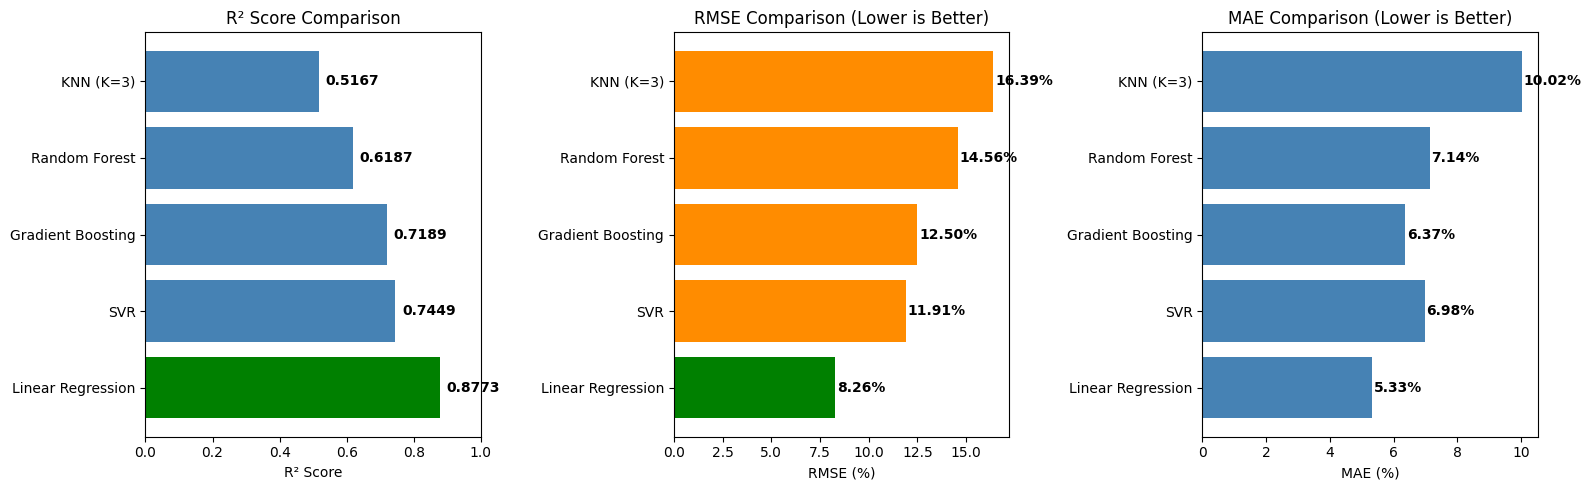

In [150]:
# Visualization comparing all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: R² Score Comparison
colors = ['green' if x == best_r2 else 'steelblue' for x in comparison_df['R² Score']]
axes[0].barh(comparison_df['Model'], comparison_df['R² Score'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_xlim([0, 1])
for i, v in enumerate(comparison_df['R² Score']):
    axes[0].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')

# Plot 2: RMSE Comparison
colors = ['green' if x == best_rmse else 'darkorange' for x in comparison_df['RMSE (%)']]
axes[1].barh(comparison_df['Model'], comparison_df['RMSE (%)'], color=colors)
axes[1].set_xlabel('RMSE (%)')
axes[1].set_title('RMSE Comparison (Lower is Better)')
for i, v in enumerate(comparison_df['RMSE (%)']):
    axes[1].text(v + 0.1, i, f'{v:.2f}%', va='center', fontweight='bold')

# Plot 3: MAE Comparison
colors = ['steelblue' for x in comparison_df['MAE (%)']]
axes[2].barh(comparison_df['Model'], comparison_df['MAE (%)'], color=colors)
axes[2].set_xlabel('MAE (%)')
axes[2].set_title('MAE Comparison (Lower is Better)')
for i, v in enumerate(comparison_df['MAE (%)']):
    axes[2].text(v + 0.05, i, f'{v:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


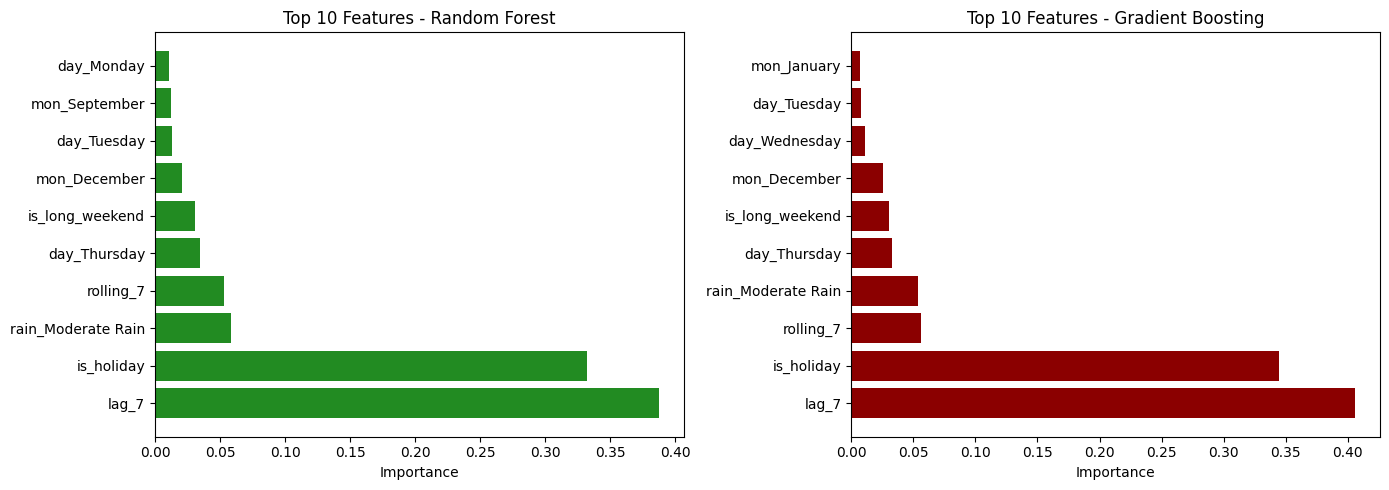


Top Features from Random Forest:
           Feature  Importance
             lag_7    0.387151
        is_holiday    0.331833
rain_Moderate Rain    0.058494
         rolling_7    0.053174
      day_Thursday    0.034862
   is_long_weekend    0.030484
      mon_December    0.021147
       day_Tuesday    0.013084
     mon_September    0.012234
        day_Monday    0.010698


Top Features from Gradient Boosting:
           Feature  Importance
             lag_7    0.405606
        is_holiday    0.344712
         rolling_7    0.055880
rain_Moderate Rain    0.053572
      day_Thursday    0.033272
   is_long_weekend    0.030204
      mon_December    0.025255
     day_Wednesday    0.010879
       day_Tuesday    0.007938
       mon_January    0.007205


In [151]:
# Feature Importance from Tree-Based Models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='forestgreen')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Features - Random Forest')

# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

axes[1].barh(gb_importance['Feature'], gb_importance['Importance'], color='darkred')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 Features - Gradient Boosting')

plt.tight_layout()
plt.show()

print("\nTop Features from Random Forest:")
print(rf_importance.to_string(index=False))

print("\n\nTop Features from Gradient Boosting:")
print(gb_importance.to_string(index=False))


In [152]:
# Prediction Comparison - First 10 Test Samples
predictions_df = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Linear Reg': lr.predict(X_test_scaled)[:10],
    f'KNN (K={optimal_k})': y_pred_knn[:10],
    'Random Forest': y_pred_rf[:10],
    'Gradient Boost': y_pred_gb[:10],
    'SVR': y_pred_svr[:10]
}).round(2)

print("\nPrediction Comparison (First 10 Test Samples):")
print("="*80)
print(predictions_df.to_string())
print("="*80)

# Calculate average prediction difference from actual
print("\nAverage Absolute Deviation from Actual:")
print("-"*40)
for col in ['Linear Reg', f'KNN (K={optimal_k})', 'Random Forest', 'Gradient Boost', 'SVR']:
    avg_dev = abs(predictions_df[col] - predictions_df['Actual']).mean()
    print(f"{col:<20}: {avg_dev:.2f}%")



Prediction Comparison (First 10 Test Samples):
   Actual  Linear Reg  KNN (K=3)  Random Forest  Gradient Boost    SVR
0   81.57       76.72      67.26          79.09           78.62  76.69
1   48.33       50.27      49.62          50.58           50.57  50.84
2   62.07       63.48      63.72          64.10           63.87  64.47
3   71.83       77.72      75.52          74.86           75.70  75.23
4   84.90       80.16      83.56          82.04           81.61  82.69
5   37.79       76.77      67.26          79.67           80.42  77.12
6    0.00      -15.05      16.88           0.00            0.49   1.88
7    9.63       39.15      65.91          54.54           41.70  56.34
8    7.69       19.80      76.41          73.92           67.57  65.01
9   80.63       57.24      81.52          16.66           20.83  57.63

Average Absolute Deviation from Actual:
----------------------------------------
Linear Reg          : 13.79%
KNN (K=3)           : 19.45%
Random Forest       : 22.96%
Gr